# E3D-0 · Unitree Go2 模型读取与可微数字孪生

**目的**：确认官方 Go2 URDF 能被正确加载与参数化，并基于 PyTorch/PyTorch3D 自建一个**端到端可微**的数字孪生（URDF → 运动学树 → 可微 FK → 刚体骨骼绑定 → 可微渲染）。

本 notebook 只作**叙事与展示**，逻辑均在可复用模块：`models/go2_urdf.py`、`models/go2_kinematics.py`、`models/go2_render.py`。

> 数据来源：`Unitree-Go2-Robot/go2_description` @ `humble` commit `8bd6717`。参数表见 `parameters/`，结论见 `reports/go2_3d_research_note.md`。

In [1]:
import sys, json
from pathlib import Path
import torch

ROOT = Path.cwd().parent  # go2_3d/
sys.path.insert(0, str(ROOT / 'models'))
from go2_urdf import load_go2, LEGS, JOINTS_PER_LEG
from go2_kinematics import Go2Kinematics

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE, '| torch', torch.__version__)

device: cuda:0 | torch 2.4.1


## 1. 加载官方 URDF，核对结构与质量

In [2]:
m = load_go2()
print(f'robot          : {m.name}')
print(f'base/root link : {m.base_link}')
print(f'links / joints : {len(m.links)} / {len(m.joints)}  (actuated: {len(m.actuated_joints)})')
print(f'total mass     : {m.total_mass:.3f} kg')
print(f'foot links     : {m.foot_links}')
print(f'frame          : URDF/ROS body frame +X fwd, +Y left, +Z up; gravity -Z')

robot          : go2_description
base/root link : base_link
links / joints : 29 / 28  (actuated: 12)
total mass     : 15.019 kg
foot links     : ['FL_foot', 'FR_foot', 'RL_foot', 'RR_foot']
frame          : URDF/ROS body frame +X fwd, +Y left, +Z up; gravity -Z


## 2. 12 个驱动关节（轴 / 限位 / 力矩 / 速度）
canonical 顺序 `LEGS=(FL,FR,RL,RR) × (hip,thigh,calf)`。

In [3]:
for j in m.actuated_joints:
    L = j.limit
    print(f"{j.name:16s} axis={j.axis.astype(int).tolist()} "
          f"lim=[{L['lower']:+.4f},{L['upper']:+.4f}] eff={L['effort']:5.2f} vel={L['velocity']:5.2f}")

FL_hip_joint     axis=[1, 0, 0] lim=[-1.0472,+1.0472] eff=23.70 vel=30.10
FL_thigh_joint   axis=[0, 1, 0] lim=[-1.5708,+3.4907] eff=23.70 vel=30.10
FL_calf_joint    axis=[0, 1, 0] lim=[-2.7227,-0.8378] eff=45.43 vel=15.70
FR_hip_joint     axis=[1, 0, 0] lim=[-1.0472,+1.0472] eff=23.70 vel=30.10
FR_thigh_joint   axis=[0, 1, 0] lim=[-1.5708,+3.4907] eff=23.70 vel=30.10
FR_calf_joint    axis=[0, 1, 0] lim=[-2.7227,-0.8378] eff=45.43 vel=15.70
RL_hip_joint     axis=[1, 0, 0] lim=[-1.0472,+1.0472] eff=23.70 vel=30.10
RL_thigh_joint   axis=[0, 1, 0] lim=[-0.5236,+4.5379] eff=23.70 vel=30.10
RL_calf_joint    axis=[0, 1, 0] lim=[-2.7227,-0.8378] eff=45.43 vel=15.70
RR_hip_joint     axis=[1, 0, 0] lim=[-1.0472,+1.0472] eff=23.70 vel=30.10
RR_thigh_joint   axis=[0, 1, 0] lim=[-0.5236,+4.5379] eff=23.70 vel=30.10
RR_calf_joint    axis=[0, 1, 0] lim=[-2.7227,-0.8378] eff=45.43 vel=15.70


## 3. 连杆惯量（质量 > 0）——SRBD 的惯量张量来源

In [4]:
for name, l in m.links.items():
    if l.inertial is None or l.inertial.mass <= 0:
        continue
    I = l.inertial.inertia_dict
    print(f"{name:12s} m={l.inertial.mass:6.3f} kg  com={l.inertial.com.round(4).tolist()}  "
          f"Idiag=({I['ixx']:.4g},{I['iyy']:.4g},{I['izz']:.4g})")

base_link    m= 6.921 kg  com=[0.0211, 0.0, -0.0054]  Idiag=(0.02448,0.09808,0.107)
Head_upper   m= 0.001 kg  com=[0.0, 0.0, 0.0]  Idiag=(9.6e-06,9.6e-06,9.6e-06)
Head_lower   m= 0.001 kg  com=[0.0, 0.0, 0.0]  Idiag=(9.6e-06,9.6e-06,9.6e-06)
FL_hip       m= 0.678 kg  com=[-0.0054, 0.0019, -0.0001]  Idiag=(0.00048,0.000884,0.000596)
FL_thigh     m= 1.152 kg  com=[-0.0037, -0.0223, -0.0327]  Idiag=(0.00584,0.0058,0.00103)
FL_calf      m= 0.154 kg  com=[0.0055, -0.001, -0.115]  Idiag=(0.00108,0.0011,3.29e-05)
FL_foot      m= 0.040 kg  com=[0.0, 0.0, 0.0]  Idiag=(9.6e-06,9.6e-06,9.6e-06)
FR_hip       m= 0.678 kg  com=[-0.0054, -0.0019, -0.0001]  Idiag=(0.00048,0.000884,0.000596)
FR_thigh     m= 1.152 kg  com=[-0.0037, 0.0223, -0.0327]  Idiag=(0.00584,0.0058,0.00103)
FR_calf      m= 0.154 kg  com=[0.0055, 0.001, -0.115]  Idiag=(0.00108,0.0011,3.29e-05)
FR_foot      m= 0.040 kg  com=[0.0, 0.0, 0.0]  Idiag=(9.6e-06,9.6e-06,9.6e-06)
RL_hip       m= 0.678 kg  com=[0.0054, 0.0019, -0.0001]  Idia

## 4. 可微前向运动学（FK）验证
零位足端位置应与参数摘要完全吻合；梯度应物理正确且有限。

In [5]:
kin = Go2Kinematics.from_urdf(device='cpu', dtype=torch.float64)
q0 = torch.zeros(1, 12, dtype=torch.float64)
feet0 = kin.foot_positions(q0)[0]
for leg, p in zip(LEGS, feet0):
    print(f'foot {leg} @ q=0 : {p.tolist()}')

q = torch.zeros(1, 12, dtype=torch.float64, requires_grad=True)
kin.foot_positions(q)[0, 0, 2].backward()  # d(FL_foot_z)/dq
g = q.grad[0].reshape(4, 3)[0]
print(f'\nd(FL_foot_z)/d[hip,thigh,calf] = {g.tolist()}  (expect [0.0955, 0, 0])')
print('FK differentiable & finite:', torch.isfinite(q.grad).all().item())

foot FL @ q=0 : [0.1934, 0.14200000000000002, -0.426]
foot FR @ q=0 : [0.1934, -0.14200000000000002, -0.426]
foot RL @ q=0 : [-0.1934, 0.14200000000000002, -0.426]
foot RR @ q=0 : [-0.1934, -0.14200000000000002, -0.426]

d(FL_foot_z)/d[hip,thigh,calf] = [0.0955, 0.0, 0.0]  (expect [0.0955, 0, 0])
FK differentiable & finite: True


## 5. 可微数字孪生渲染 + 端到端可微性
刚体骨骼绑定：每连杆网格经 FK 世界变换后 `join_meshes_as_scene` 合成一个场景 Mesh。

/home/misaka/anaconda3/envs/pytorch/lib/python3.9/site-packages/pytorch3d/io/obj_io.py:546: UserWarning: No mtl file provided
  warnings.warn("No mtl file provided")


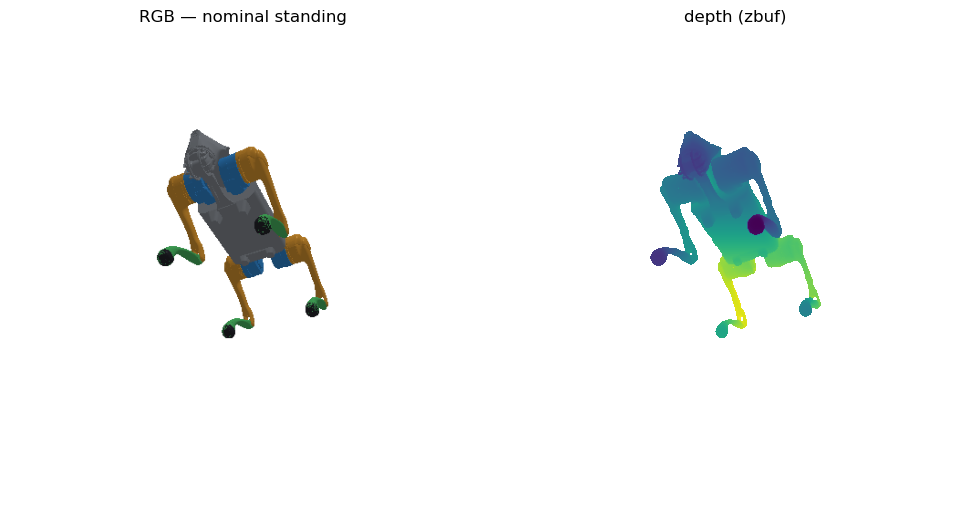

foot z (standing): [-0.265, -0.265, -0.265, -0.265] | base height above feet ~ 0.265 m


In [6]:
import matplotlib.pyplot as plt
from go2_render import Go2Twin

twin = Go2Twin(device=DEVICE, dtype=torch.float32)
q_stand = torch.tensor([[0.0, 0.9, -1.8] * 4], dtype=torch.float32)
rgb, depth = twin.render(q_stand, image_size=512, azim=135.0)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(rgb[0].clip(0, 1)); ax[0].set_title('RGB — nominal standing'); ax[0].axis('off')
d = depth[0].copy(); d[d < 0] = float('nan')
ax[1].imshow(d, cmap='viridis'); ax[1].set_title('depth (zbuf)'); ax[1].axis('off')
plt.tight_layout(); plt.show()

feet = twin.kin.foot_positions(q_stand.to(twin.device, twin.dtype))[0]
print('foot z (standing):', [round(z, 3) for z in feet[:, 2].tolist()],
      '| base height above feet ~', round(-feet[:, 2].mean().item(), 3), 'm')

In [7]:
# 端到端可微性：像素 -> q 梯度
qg = q_stand.to(twin.device, twin.dtype).requires_grad_(True)
rgb_t, _ = twin.render(qg, image_size=128, return_tensor=True)
rgb_t.mean().backward()
print(f'd(mean pixel)/dq norm = {qg.grad.norm().item():.3e}  '
      f'finite={torch.isfinite(qg.grad).all().item()}  '
      f'nonzero={(qg.grad.abs() > 0).sum().item()}/12')

d(mean pixel)/dq norm = 6.498e-03  finite=True  nonzero=12/12


## 6. 结论（E3D-0）

- 官方 Go2 URDF 已正确加载：**29 连杆 / 28 关节 / 12 驱动，总质量 15.019 kg**，参数逐项可追溯（commit `8bd6717`）。
- 自建 **FK 数值正确**（零位足端吻合）、**梯度物理正确**（`d(foot_z)/d(hip)=0.0955`=侧向力臂）。
- **可微数字孪生成立**：DAE→OBJ + 刚体蒙皮 + PyTorch3D 渲染装配正确、单位米、机身直立；像素→`q` 梯度有限且 12 维全非零。
- 验收 §12-Q1 ✅：Go2 数字模型已正确加载与参数化。

下一步 E3D-1：把浮动基位姿接上 3D 单刚体动力学（四元数积分 + 惯量张量）。详见 `reports/go2_3d_research_note.md`。